# v3 Ablation + v4/v5 Real PD Fine-tuning — vs run_002_v2 Baseline

Compares 6 v3 ablations + 4 real PD experiments against the best baseline (run_002_v2, Dice=0.6854).

| Run | Base checkpoint | Training data |
|---|---|---|
| **run_002_v2** | baseline_best_model.pth | fake PD — Dice=0.6854 |
| **v3_rotation** | run_002_v2 | fake PD + rotation aug |
| **v3_tversky** | run_002_v2 | fake PD + Tversky loss |
| **v3_resnet50** | run_002_v2 | fake PD + ResNet50 |
| **v3_5slice** | run_002_v2 | fake PD + 5-slice context |
| **v3_elastic** | run_002_v2 | fake PD + elastic aug |
| **v3_photometric** | run_002_v2 | fake PD + photometric aug |
| **v4_realPD** | run_002_v2 | real PD (D2) only — MergedLoss |
| **v4_mixed** | run_002_v2 | real PD (D2) + fake PD |
| **v5_realPD** | baseline_best_model.pth | real PD (D2) only — MergedLoss |
| **v5_mixed** | baseline_best_model.pth | real PD (D2) + fake PD |


In [23]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom

In [24]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE   = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES    = f"{BASE}/results"

PD_DIR = f"{BASE}/data/iu-dataset/pd-files"
GT_DIR = f"{BASE}/data/iu-dataset/segmentation_masks"

PRED_R002V2_DIR      = f"{RES}/real_pd_predictions_run002_v2"
PRED_V3_ROTATION_DIR = f"{RES}/real_pd_predictions_v3_rotation"
PRED_V3_TVERSKY_DIR  = f"{RES}/real_pd_predictions_v3_tversky"
PRED_V3_R50_DIR      = f"{RES}/real_pd_predictions_v3_resnet50"
PRED_V3_5SLICE_DIR   = f"{RES}/real_pd_predictions_v3_5slice"
PRED_V3_ELASTIC_DIR  = f"{RES}/real_pd_predictions_v3_elastic"
PRED_V3_PHOTO_DIR    = f"{RES}/real_pd_predictions_v3_photometric"
PRED_V4_REALPD_DIR   = f"{RES}/real_pd_predictions_v4_realPD"
PRED_V4_MIXED_DIR    = f"{RES}/real_pd_predictions_v4_mixed"
PRED_V5_REALPD_DIR   = f"{RES}/real_pd_predictions_v5_realPD"
PRED_V5_MIXED_DIR    = f"{RES}/real_pd_predictions_v5_mixed"

In [25]:
def extract_patient_id(path):
    return Path(path).name.split("_")[0]

def patients_in_dir(directory, pattern="*.nii*"):
    files = glob.glob(os.path.join(directory, pattern))
    return {extract_patient_id(f): f for f in files
            if ".seg.nrrd" not in f and ".labels.csv" not in f}

def load_vol(path):
    img = nib.load(path)
    return np.asarray(img.get_fdata()), img.affine

def preprocess_gt_mask(path):
    img = nib.load(path)
    img = nib.as_closest_canonical(img)
    arr = img.get_fdata().astype(np.float32)
    zooms = img.header.get_zooms()[:3]
    sp_A, sp_S = float(zooms[1]), float(zooms[2])
    target_ip  = min(sp_A, sp_S)
    fa, fs = sp_A / target_ip, sp_S / target_ip
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=0)
    return arr

def preprocess_pd_image(path):
    img = nib.load(path)
    img = nib.as_closest_canonical(img)
    arr = img.get_fdata().astype(np.float32)
    zooms = img.header.get_zooms()[:3]
    sp_A, sp_S = float(zooms[1]), float(zooms[2])
    target_ip  = min(sp_A, sp_S)
    fa, fs = sp_A / target_ip, sp_S / target_ip
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=3, prefilter=True)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=3)
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo + 1e-8)
    return arr

def merge_meniscus(pred):
    """3-class (0=bg, 1=lat, 2=med) → binary meniscus."""
    return (pred > 0).astype(bool)

def dice_score(pred_bin, gt_bin):
    intersection = (pred_bin & gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    if denom == 0:
        return 1.0
    return float(2 * intersection / denom)

In [26]:
# ── Find common patients across all runs ─────────────────────────────────────
gt_patients      = patients_in_dir(GT_DIR,               "*.nii")
r002v2_patients  = patients_in_dir(PRED_R002V2_DIR,      "*.nii.gz")
rot_patients     = patients_in_dir(PRED_V3_ROTATION_DIR, "*.nii.gz")
tvk_patients     = patients_in_dir(PRED_V3_TVERSKY_DIR,  "*.nii.gz")
r50_patients     = patients_in_dir(PRED_V3_R50_DIR,      "*.nii.gz")
sl5_patients     = patients_in_dir(PRED_V3_5SLICE_DIR,   "*.nii.gz")
ela_patients     = patients_in_dir(PRED_V3_ELASTIC_DIR,  "*.nii.gz")
pho_patients     = patients_in_dir(PRED_V3_PHOTO_DIR,    "*.nii.gz")
v4rpd_patients   = patients_in_dir(PRED_V4_REALPD_DIR,   "*.nii.gz")
v4mix_patients   = patients_in_dir(PRED_V4_MIXED_DIR,    "*.nii.gz")
v5rpd_patients   = patients_in_dir(PRED_V5_REALPD_DIR,   "*.nii.gz")
v5mix_patients   = patients_in_dir(PRED_V5_MIXED_DIR,    "*.nii.gz")

all_dirs = {
    "GT":            gt_patients,
    "run_002_v2":    r002v2_patients,
    "v3_rotation":   rot_patients,
    "v3_tversky":    tvk_patients,
    "v3_resnet50":   r50_patients,
    "v3_5slice":     sl5_patients,
    "v3_elastic":    ela_patients,
    "v3_photometric":pho_patients,
    "v4_realPD":     v4rpd_patients,
    "v4_mixed":      v4mix_patients,
    "v5_realPD":     v5rpd_patients,
    "v5_mixed":      v5mix_patients,
}

# Use runs that have predictions available (skip empty dirs)
available = {k: v for k, v in all_dirs.items() if len(v) > 0}

for name, d in all_dirs.items():
    status = f"{len(d)} patients" if len(d) > 0 else "NOT FOUND — skip"
    print(f"{name:<20}: {status}")

common = sorted(set.intersection(*[set(v.keys()) for v in available.values()]))
print(f"\nCommon across available: {len(common)}")
print(f"IDs: {common}")

GT                  : 10 patients
run_002_v2          : 8 patients
v3_rotation         : 8 patients
v3_tversky          : 8 patients
v3_resnet50         : 8 patients
v3_5slice           : 8 patients
v3_elastic          : 8 patients
v3_photometric      : 8 patients
v4_realPD           : 8 patients
v4_mixed            : 8 patients
v5_realPD           : 8 patients
v5_mixed            : 8 patients

Common across available: 8
IDs: ['AC0D3459553205', 'AC0D5A4D78B628', 'AC0D7BF72F7712', 'AC111633B463BB', 'AC13300201B926', 'AC149BC218E75C', 'AC14D3737C0482', 'AC19E7C19827FF']


In [27]:
# ── Compute Dice for all available runs ──────────────────────────────────────
results = []

for pid in common:
    gt = preprocess_gt_mask(gt_patients[pid])
    gt_bin = (gt == 1).astype(bool)

    row = {"patient": pid, "_gt": gt}

    for run_name, pdict in available.items():
        if run_name == "GT":
            continue
        if pid in pdict:
            vol, _ = load_vol(pdict[pid])
            row[f"_pred_{run_name}"] = vol
            row[f"dice_{run_name}"]  = dice_score(merge_meniscus(vol), gt_bin)
        else:
            row[f"_pred_{run_name}"] = None
            row[f"dice_{run_name}"]  = float("nan")

    results.append(row)

    line = f"{pid}  "
    for run_name in available:
        if run_name == "GT": continue
        line += f"{run_name}={row.get(f'dice_{run_name}', float('nan')):.3f}  "
    print(line)

run_names = [k for k in available if k != "GT"]
means = {}
for run_name in run_names:
    vals = [r[f"dice_{run_name}"] for r in results if not np.isnan(r.get(f"dice_{run_name}", float("nan")))]
    means[run_name] = np.mean(vals) if vals else float("nan")

print("\nMEAN Dice:")
for run_name, m in means.items():
    print(f"  {run_name:<20}: {m:.4f}")

best_run = max(means, key=lambda k: means[k])
print(f"\nBEST: {best_run}  Dice={means[best_run]:.4f}")

AC0D3459553205  run_002_v2=0.659  v3_rotation=0.668  v3_tversky=0.665  v3_resnet50=0.678  v3_5slice=0.581  v3_elastic=0.703  v3_photometric=0.682  v4_realPD=0.769  v4_mixed=0.739  v5_realPD=0.144  v5_mixed=0.727  
AC0D5A4D78B628  run_002_v2=0.601  v3_rotation=0.651  v3_tversky=0.619  v3_resnet50=0.571  v3_5slice=0.250  v3_elastic=0.568  v3_photometric=0.636  v4_realPD=0.733  v4_mixed=0.720  v5_realPD=0.114  v5_mixed=0.730  
AC0D7BF72F7712  run_002_v2=0.696  v3_rotation=0.679  v3_tversky=0.627  v3_resnet50=0.490  v3_5slice=0.452  v3_elastic=0.681  v3_photometric=0.642  v4_realPD=0.758  v4_mixed=0.728  v5_realPD=0.129  v5_mixed=0.762  
AC111633B463BB  run_002_v2=0.745  v3_rotation=0.757  v3_tversky=0.729  v3_resnet50=0.750  v3_5slice=0.576  v3_elastic=0.696  v3_photometric=0.765  v4_realPD=0.820  v4_mixed=0.808  v5_realPD=0.136  v5_mixed=0.823  
AC13300201B926  run_002_v2=0.726  v3_rotation=0.677  v3_tversky=0.688  v3_resnet50=0.679  v3_5slice=0.514  v3_elastic=0.651  v3_photometric=0.67

In [28]:
# ── Summary table ─────────────────────────────────────────────────────────────
header = f"{'Patient':<22}" + "".join(f"{n:>15}" for n in run_names)
print(header)
print("-" * len(header))

for r in results:
    row_str = f"{r['patient']:<22}"
    for run_name in run_names:
        d = r.get(f"dice_{run_name}", float("nan"))
        row_str += f"{d:>15.4f}"
    print(row_str)

print("-" * len(header))
mean_str = f"{'MEAN':<22}"
for run_name in run_names:
    mean_str += f"{means[run_name]:>15.4f}"
print(mean_str)

print("\n── Improvement over run_002_v2 baseline (0.6854) ──")
baseline = means.get("run_002_v2", float("nan"))
for run_name in run_names:
    if run_name == "run_002_v2": continue
    delta = means[run_name] - baseline
    sign = "+" if delta >= 0 else ""
    winner = " ◄ WIN" if delta > 0 else ""
    print(f"  {run_name:<22}: {sign}{delta*100:.2f}%{winner}")

print("\n── Ranking ──")
ranked = sorted(means.items(), key=lambda x: -x[1])
for i, (name, score) in enumerate(ranked, 1):
    star = " ◄ BEST" if i == 1 else ""
    print(f"  {i}. {name:<22} {score:.4f}{star}")

Patient                    run_002_v2    v3_rotation     v3_tversky    v3_resnet50      v3_5slice     v3_elastic v3_photometric      v4_realPD       v4_mixed      v5_realPD       v5_mixed
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AC0D3459553205                 0.6590         0.6678         0.6647         0.6776         0.5806         0.7027         0.6823         0.7690         0.7390         0.1441         0.7271
AC0D5A4D78B628                 0.6013         0.6512         0.6186         0.5710         0.2500         0.5685         0.6356         0.7325         0.7205         0.1138         0.7299
AC0D7BF72F7712                 0.6962         0.6786         0.6273         0.4897         0.4518         0.6813         0.6420         0.7576         0.7278         0.1294         0.7618
AC111633B463BB                 0.7449         0.7572        

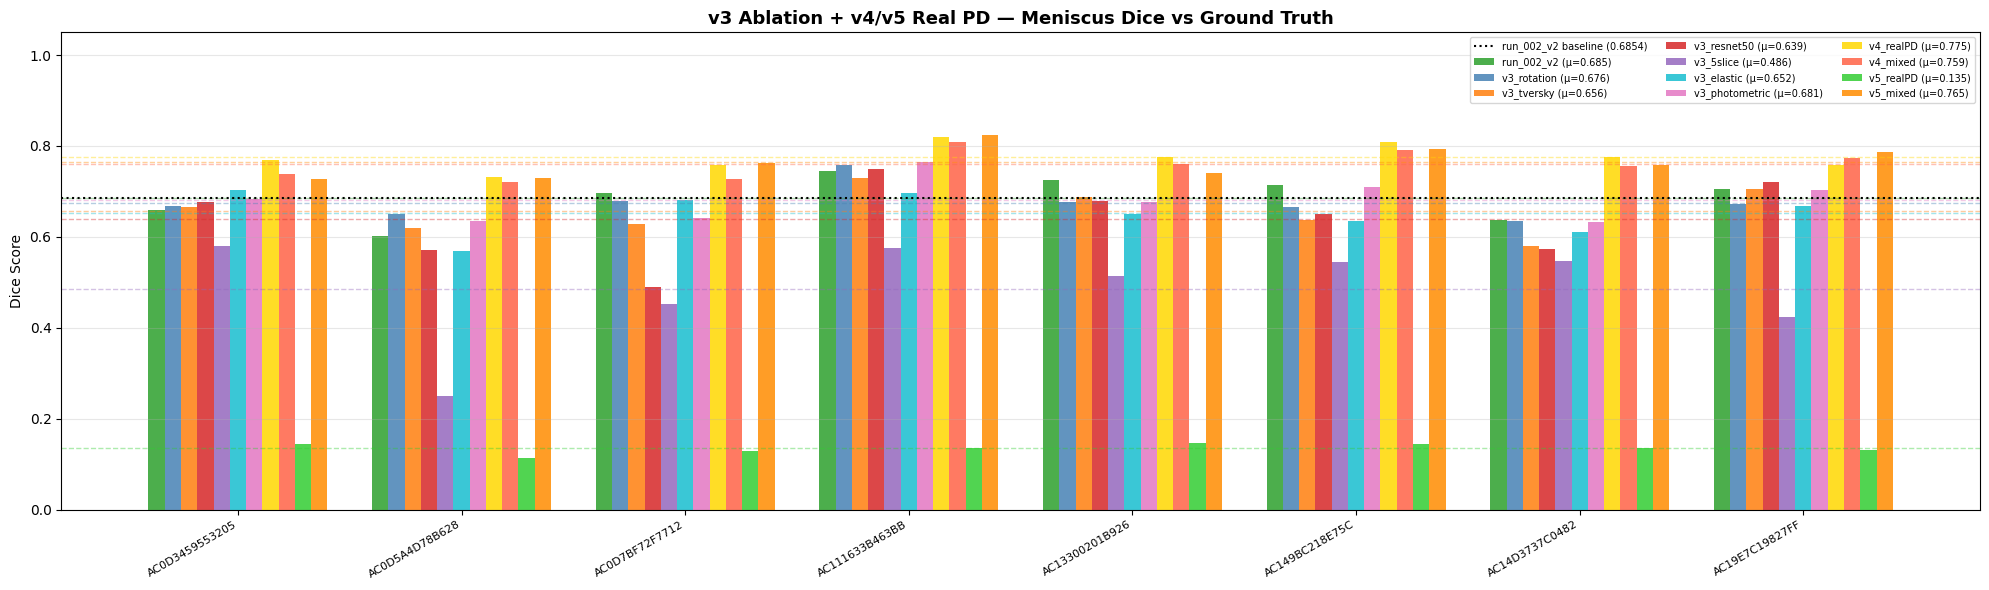

In [29]:
# ── Bar chart: Dice per patient — all runs ────────────────────────────────────
COLORS = {
    "run_002_v2":    "tab:green",
    "v3_rotation":   "steelblue",
    "v3_tversky":    "tab:orange",
    "v3_resnet50":   "tab:red",
    "v3_5slice":     "tab:purple",
    "v3_elastic":    "tab:cyan",
    "v3_photometric":"tab:pink",
    "v4_realPD":     "gold",
    "v4_mixed":      "tomato",
    "v5_realPD":     "limegreen",
    "v5_mixed":      "darkorange",
}

patients = [r["patient"] for r in results]
x = np.arange(len(patients))
n_runs = len(run_names)
w = 0.8 / n_runs
offsets = np.linspace(-(n_runs-1)*w/2, (n_runs-1)*w/2, n_runs)

fig, ax = plt.subplots(figsize=(max(16, len(patients)*2.5), 6))
for i, run_name in enumerate(run_names):
    dice_vals = [r.get(f"dice_{run_name}", float("nan")) for r in results]
    m = means[run_name]
    color = COLORS.get(run_name, "gray")
    ax.bar(x + offsets[i], dice_vals, w, label=f"{run_name} (μ={m:.3f})",
           color=color, alpha=0.85)
    ax.axhline(m, color=color, linestyle="--", alpha=0.4, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Dice Score")
ax.set_ylim(0, 1.05)
ax.set_title("v3 Ablation + v4/v5 Real PD — Meniscus Dice vs Ground Truth", fontweight="bold", fontsize=13)
ax.axhline(0.6854, color="black", linestyle=":", linewidth=1.5, label="run_002_v2 baseline (0.6854)")
ax.legend(loc="upper right", fontsize=7, ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/dice_comparison_v3.png", dpi=150)
plt.show()

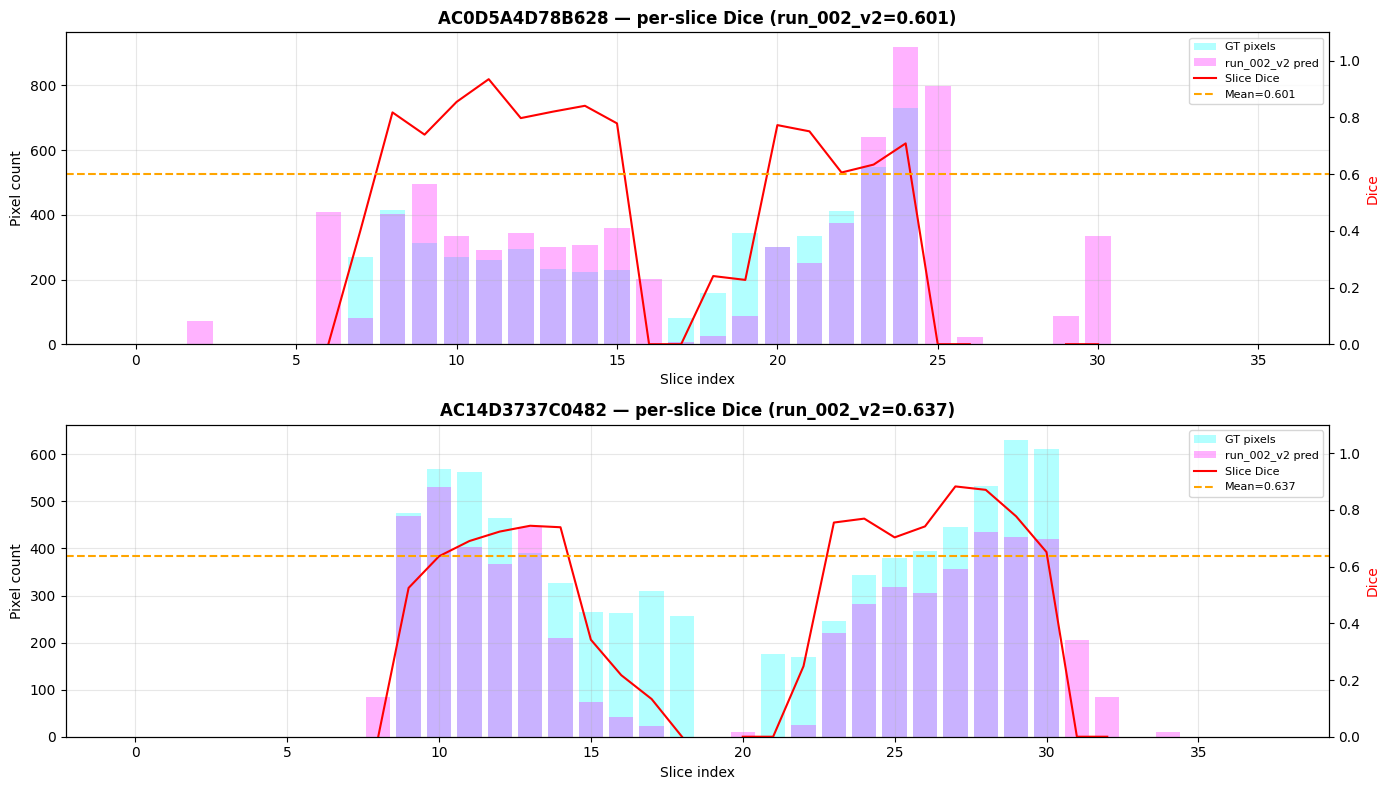

In [30]:
# ── Per-slice Dice — worst 2 patients (run_002_v2) for reference ──────────────
if "run_002_v2" in run_names:
    worst2 = sorted(results, key=lambda x: x.get("dice_run_002_v2", 1.0))[:2]

    fig, axes = plt.subplots(len(worst2), 1, figsize=(14, 4 * len(worst2)), facecolor="white")
    if len(worst2) == 1:
        axes = [axes]

    for ax, r in zip(axes, worst2):
        gt      = (r["_gt"] == 1).astype(bool)
        pred    = r.get("_pred_run_002_v2")
        if pred is None:
            ax.set_title(f"{r['patient']} — no run_002_v2 predictions")
            continue
        pred_bin = merge_meniscus(pred)

        slice_dice = []
        for s in range(gt.shape[0]):
            tp = (pred_bin[s] & gt[s]).sum()
            denom = pred_bin[s].sum() + gt[s].sum()
            slice_dice.append(float(2 * tp / denom) if denom > 0 else float("nan"))

        slices = range(gt.shape[0])
        ax2 = ax.twinx()
        ax.bar(slices, gt.sum(axis=(1,2)),       alpha=0.3, color="cyan",    label="GT pixels")
        ax.bar(slices, pred_bin.sum(axis=(1,2)), alpha=0.3, color="magenta", label="run_002_v2 pred")
        ax2.plot(slices, slice_dice, color="red", linewidth=1.5, label="Slice Dice")
        mean_d = r.get("dice_run_002_v2", float("nan"))
        ax2.axhline(mean_d, color="orange", linestyle="--", label=f"Mean={mean_d:.3f}")
        ax2.set_ylim(0, 1.1); ax2.set_ylabel("Dice", color="red")
        ax.set_xlabel("Slice index"); ax.set_ylabel("Pixel count")
        ax.set_title(f"{r['patient']} — per-slice Dice (run_002_v2={mean_d:.3f})", fontweight="bold")
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{BASE}/per_slice_dice_v3.png", dpi=150)
    plt.show()

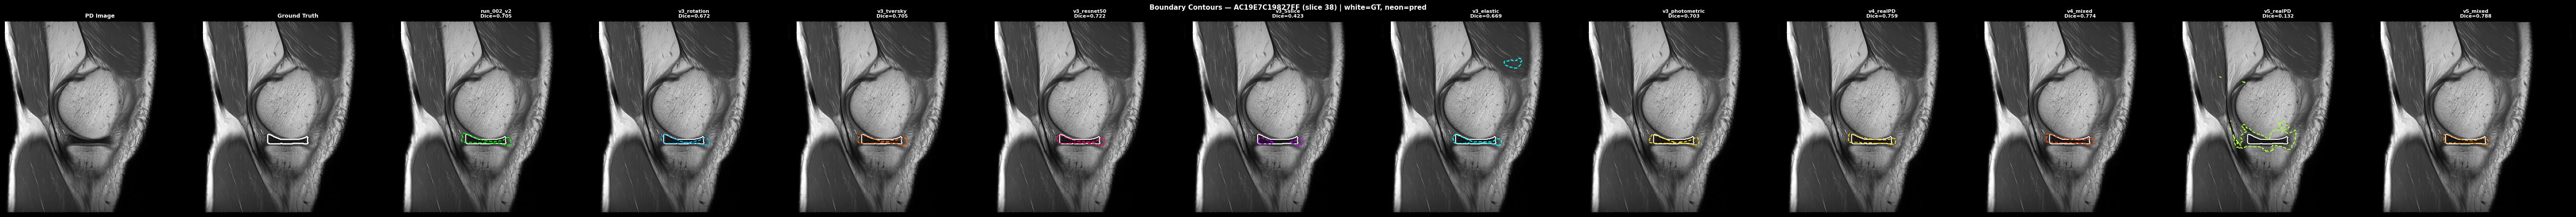

In [31]:
# ── Boundary contour overlay — best patient, all runs ─────────────────────
from matplotlib.lines import Line2D

NEON = [
    ("run_002_v2",     "#00FF00"),
    ("v3_rotation",    "#00BFFF"),
    ("v3_tversky",     "#FF6600"),
    ("v3_resnet50",    "#FF0066"),
    ("v3_5slice",      "#CC00FF"),
    ("v3_elastic",     "#00FFFF"),
    ("v3_photometric", "#FFD700"),
    ("v4_realPD",      "#FFD700"),
    ("v4_mixed",       "#FF4500"),
    ("v5_realPD",      "#ADFF2F"),
    ("v5_mixed",       "#FF8C00"),
]

best_pid = max(common, key=lambda pid: next(
    (r["_gt"] == 1).sum() for r in results if r["patient"] == pid
))
r = next(x for x in results if x["patient"] == best_pid)
gt_bin = (r["_gt"] == 1).astype(bool)
best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))

pd_files = glob.glob(os.path.join(PD_DIR, f"{best_pid}*.nii*"))
pd_sl = np.zeros((384, 384), dtype=float)
if pd_files:
    pd_vol = preprocess_pd_image(pd_files[0])
    if pd_vol.shape[0] != r["_gt"].shape[0]:
        pd_vol = zoom(pd_vol, (r["_gt"].shape[0] / pd_vol.shape[0], 1.0, 1.0), order=3)
    pd_sl = pd_vol[best_sl]

available_neon = [(name, color) for name, color in NEON if f"_pred_{name}" in r and r[f"_pred_{name}"] is not None]
n_panels = len(available_neon) + 2

fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 5), facecolor="black")

axes[0].set_facecolor("black")
axes[0].imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[0].set_title("PD Image", color="white", fontsize=9, fontweight="bold")
axes[0].axis("off")

axes[1].set_facecolor("black")
axes[1].imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
if gt_bin[best_sl].any():
    axes[1].contour(gt_bin[best_sl].T, levels=[0.5], colors=["#FFFFFF"], linewidths=2.0)
axes[1].set_title("Ground Truth", color="white", fontsize=9, fontweight="bold")
axes[1].axis("off")

for i, (run_name, color) in enumerate(available_neon):
    ax = axes[i + 2]
    ax.set_facecolor("black")
    ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    if gt_bin[best_sl].any():
        ax.contour(gt_bin[best_sl].T, levels=[0.5], colors=["#FFFFFF"], linewidths=1.5, linestyles="solid")
    pred = merge_meniscus(r[f"_pred_{run_name}"])
    if pred[best_sl].any():
        ax.contour(pred[best_sl].T, levels=[0.5], colors=[color], linewidths=1.5, linestyles="dashed")
    d = r.get(f"dice_{run_name}", float("nan"))
    ax.set_title(f"{run_name}\nDice={d:.3f}", color="white", fontsize=8, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"Boundary Contours — {best_pid} (slice {best_sl}) | white=GT, neon=pred",
             fontsize=11, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig(f"{BASE}/boundary_comparison_v3.png", dpi=150, facecolor="black")
plt.show()

In [32]:
# ── Final ranking + notes ──────────────────────────────────────────────────────
print("=" * 65)
print("FINAL RANKING (v3 Ablation + v4/v5 Real PD)")
print("=" * 65)

baseline_dice = means.get("run_002_v2", float("nan"))
ranked = sorted(means.items(), key=lambda x: -x[1])

for i, (name, score) in enumerate(ranked, 1):
    delta = score - baseline_dice
    sign  = "+" if delta >= 0 else ""
    star  = " ◄ BEST" if i == 1 else ""
    base_marker = " (BASELINE)" if name == "run_002_v2" else f"  [{sign}{delta*100:.2f}% vs baseline]"
    print(f"  {i}. {name:<22} Dice={score:.4f}{base_marker}{star}")

print()
print("── What each experiment changed ──")
notes = {
    "run_002_v2":    "BASELINE — from DESS baseline, fake PD data, CE+SoftDice",
    "v3_rotation":   "from run_002_v2 + rotation aug ±15°",
    "v3_tversky":    "from run_002_v2 + Tversky loss (α=0.3, β=0.7)",
    "v3_resnet50":   "from run_002_v2 + ResNet50 encoder",
    "v3_5slice":     "from run_002_v2 + 5-slice context",
    "v3_elastic":    "from run_002_v2 + elastic deformation aug",
    "v3_photometric":"from run_002_v2 + photometric aug",
    "v4_realPD":     "from run_002_v2 → real PD (D2) only, MergedLoss",
    "v4_mixed":      "from run_002_v2 → real PD (D2) + fake PD, MergedLoss+CE/Dice",
    "v5_realPD":     "from DESS baseline → real PD (D2) only, MergedLoss",
    "v5_mixed":      "from DESS baseline → real PD (D2) + fake PD, MergedLoss+CE/Dice",
}
for name in run_names:
    print(f"  {name:<22}: {notes.get(name, '')}")

FINAL RANKING (v3 Ablation + v4/v5 Real PD)
  1. v4_realPD              Dice=0.7748  [+8.94% vs baseline] ◄ BEST
  2. v5_mixed               Dice=0.7652  [+7.97% vs baseline]
  3. v4_mixed               Dice=0.7594  [+7.39% vs baseline]
  4. run_002_v2             Dice=0.6854 (BASELINE)
  5. v3_photometric         Dice=0.6807  [-0.48% vs baseline]
  6. v3_rotation            Dice=0.6756  [-0.98% vs baseline]
  7. v3_tversky             Dice=0.6562  [-2.92% vs baseline]
  8. v3_elastic             Dice=0.6517  [-3.38% vs baseline]
  9. v3_resnet50            Dice=0.6390  [-4.64% vs baseline]
  10. v3_5slice              Dice=0.4859  [-19.95% vs baseline]
  11. v5_realPD              Dice=0.1351  [-55.03% vs baseline]

── What each experiment changed ──
  run_002_v2            : BASELINE — from DESS baseline, fake PD data, CE+SoftDice
  v3_rotation           : from run_002_v2 + rotation aug ±15°
  v3_tversky            : from run_002_v2 + Tversky loss (α=0.3, β=0.7)
  v3_resnet50        